In [253]:
import os
import requests
import json
from dotenv import load_dotenv
# from langchain_openai import ChatOpenAI
from langchain_community.utilities.sql_database import SQLDatabase
# from langchain_experimental.sql import SQLDatabaseSequentialChain
# from langchain_community.utilities.sql_database import SQLDatabase
from langchain_core.prompts import MessagesPlaceholder, ChatPromptTemplate
from langchain_core.prompts import PromptTemplate
from typing_extensions import Annotated, TypedDict
from langchain_community.tools.sql_database.tool import QuerySQLDataBaseTool
# from langchain_community.utilities.sql_database import SQLDatabase
from sqlalchemy import create_engine
from langgraph.prebuilt import create_react_agent
from langgraph_supervisor import create_supervisor
from langchain_openai import ChatOpenAI
import time 
import yaml
import json 
from langchain_community.agent_toolkits import JsonToolkit, create_json_agent
from langchain_community.tools.json.tool import JsonSpec
from langchain_openai import OpenAI
from langchain.tools import Tool
import openai 

In [254]:
THINGSBOARD_URL = "http://localhost:8080"
USERNAME = "tenant@thingsboard.org"
PASSWORD = "tenant"
DASHBOARD_ID = "http://localhost:8080/tenants"

DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "thingsboard"
DB_USER = "thingsboard"
DB_PASSWORD = "postgres"


THINGSBOARD_HOST = "http://localhost:8080"
USERNAME = "tenant@thingsboard.org"
PASSWORD = "tenant"

load_dotenv()
openai_api_key = os.getenv('OPENAI_PROJECT_API_KEY')
client = openai.OpenAI(api_key=openai_api_key)
llm_model = "gpt-3.5-turbo"

In [414]:
# Load farm metadata 
with open("/Users/george/Documents/final_push/function-calling-for-sensors-at-the-edge/farm_model_small_v2.json", "r") as file:
    data = json.load(file)

In [415]:
# Authenticate with ThingsBoard
def authenticate():
    auth_url = f"{THINGSBOARD_URL}/api/auth/login"
    payload = {'username': USERNAME, 'password': PASSWORD}
    response = requests.post(auth_url, json=payload)
    response.raise_for_status()
    return response.json()['token']

In [416]:
jwt_token = authenticate()

In [417]:
# data

In [418]:
# create tool
tools = [
    {
        "type": "function",
        "function": {
            "name": "get_farm_details",
            "description": "Return details about a specific farm field as a JSON object.",
            "parameters": {
                "type": "object",
                "properties": {
                    "a": {
                        "type": "integer",
                        "description": "The index of the field to retrieve details for (0-based).",
                    },
                },
                "required": ["a"],
            },
        },
    }
]

In [419]:
def get_farm_details(a: int) -> str:
    """Return Farm field details as a JSON string

    Args:
        a: Field Index
    """
    try:
        field_data = data['farm']['fields'][a]
        return json.dumps(field_data)
    except IndexError:
        return json.dumps({"error": f"Field index {a} is out of bounds."})
    except KeyError:
        return json.dumps({"error": "The 'farm' or 'fields' key was not found in the data."})
    except Exception as e:
        return json.dumps({"error": f"An error occurred: {e}"})

In [420]:
# def sensor_extraction_agent(query):
#     """Runs a conversation with the LLM that can call the get_farm_details tool."""
#     messages = [
#         {"role": "system", "content": "You are a helpful assistant that identifies relevant devices (sensor_list) mentioned in the user's request and returns them as a JSON array of their IDs e.g. If no specific devices are mentioned, return an empty JSON array."
#         "F001 is North Field,"
#         "F002 is Northeast Field"
#         "F003 is East Field"
#         "F004 is Southeast Field"
#         "F005 is South Field"
#         "F006 is Southwest Field"
#         "F007 is West Field"
#         "F008 is Northwest Field"
#         "F009 is Central Field"
#         "Note: if the right Field is not provided return an empty json"
#         },
     
#         {"role": "user", "content": query}
#     ]

#     response = client.chat.completions.create(
#         model="gpt-3.5-turbo",
#         messages=messages,
#         tools=tools,
#         tool_choice="auto", 
#     )

#     response_message = response.choices[0].message

#     if response_message.tool_calls:
#         print("LLM initiated a tool call:")
#         # print(response_message.tool_calls)

#         tool_call = response_message.tool_calls[0]
#         function_name = tool_call.function.name
#         function_to_call = globals()[function_name]
#         function_args = json.loads(tool_call.function.arguments)
#         function_response = function_to_call(**function_args)

#         # Logging 
#         # print(f"Calling function '{function_name}' with arguments: {function_args}")
#         # print(f"Function returned: {function_response}")

#         messages.append(response_message)
#         messages.append(
#             {
#                 "tool_call_id": tool_call.id,
#                 "role": "tool",
#                 "name": function_name,
#                 "content": function_response,
#             }
#         )
#         second_response = client.chat.completions.create(
#             # model="gpt-3.5-turbo-0613",
#             model="gpt-3.5-turbo",
#             messages=messages,
#         )
        
#         return second_response.choices[0].message.content
#     else:
#         # If no tool call, the LLM might be directly answering based on the system prompt
#         try:
#             # Attempt to parse the response as JSON (assuming it followed the system prompt)
#             return json.loads(response_message.content)
#         except (json.JSONDecodeError, TypeError):
#             # If it's not valid JSON, return the raw content
#             return response_message.content

In [421]:
# def sensor_extraction_agent(query):
#     messages = [
#         {
#             "role": "system",
#             "content": (
#                 "You are a helpful assistant that identifies relevant devices (sensor_list) mentioned in the user's "
#                 "request and returns them as a JSON array of their IDs. "
#                 "Field mappings: F001 is North Field, F002 is Northeast Field, F003 is East Field, "
#                 "F004 is Southeast Field, F005 is South Field, F006 is Southwest Field, "
#                 "F007 is West Field, F008 is Northwest Field, F009 is Central Field. "
#                 "If the right field is not provided, return an empty JSON array."
#             ),
#         },
#         {"role": "user", "content": query},
#     ]

#     response = client.chat.completions.create(
#         model="gpt-3.5-turbo",
#         messages=messages,
#         tools=tools,
#         tool_choice="auto",
#     )

#     response_message = response.choices[0].message

#     if hasattr(response_message, 'tool_calls') and response_message.tool_calls:
#         tool_responses = []

#         for tool_call in response_message.tool_calls:
#             function_name = tool_call.function.name
#             function_to_call = globals().get(function_name)
#             if not function_to_call:
#                 continue  # Skip if the function is not defined

#             function_args = json.loads(tool_call.function.arguments)
#             function_response = function_to_call(**function_args)

#             tool_responses.append({
#                 "tool_call_id": tool_call.id,
#                 "role": "tool",
#                 "name": function_name,
#                 "content": function_response,
#             })

#         # Append the assistant's message and all tool responses to the message history
#         messages.append(response_message)
#         messages.extend(tool_responses)

#         # Send the updated message history back to the model
#         second_response = client.chat.completions.create(
#             model="gpt-3.5-turbo",
#             messages=messages,
#         )

#         return second_response.choices[0].message.content
#     else:
#         # If no tool call, attempt to parse the response as JSON
#         try:
#             return json.loads(response_message.content)
#         except (json.JSONDecodeError, TypeError):
#             return response_message.content


In [439]:
def sensor_extraction_agent(query):
    messages = [
        {
            "role": "system",
            "content": (
                "You are a helpful assistant that identifies all relevant sensors mentioned in the user's request "
                "and returns them as a JSON array of their IDs, in this format: "
                '{"sensors": ["TEMP-0100", "TEMP-0700", ...]}. '
                "Match the user's field names to the following mappings:\n"
                "- F001: North Field\n"
                "- F002: Northeast Field\n"
                "- F003: East Field\n"
                "- F004: Southeast Field\n"
                "- F005: South Field\n"
                "- F006: Southwest Field\n"
                "- F007: West Field\n"
                "- F008: Northwest Field\n"
                "- F009: Central Field\n"
                "Extract sensors only from the fields mentioned. If no valid field is provided, return an empty JSON array.Do not hallucinate sensor device"
            ),
        },
        {"role": "user", "content": query},
    ]


    response = client.chat.completions.create(
        model="gpt-3.5-turbo",
        messages=messages,
        tools=tools,
        tool_choice="auto",
    )

    response_message = response.choices[0].message

    if hasattr(response_message, 'tool_calls') and response_message.tool_calls:
        tool_responses = []

        for tool_call in response_message.tool_calls:
            function_name = tool_call.function.name
            function_to_call = globals().get(function_name)
            if not function_to_call:
                continue  # Skip if the function is not defined

            function_args = json.loads(tool_call.function.arguments)
            function_response = function_to_call(**function_args)

            tool_responses.append({
                "tool_call_id": tool_call.id,
                "role": "tool",
                "name": function_name,
                "content": function_response,
            })

        # Append the assistant's message and all tool responses to the message history
        messages.append(response_message)
        messages.extend(tool_responses)

        # Send the updated message history back to the model
        second_response = client.chat.completions.create(
            model="gpt-3.5-turbo",
            messages=messages,
        )

        return second_response.choices[0].message.content
    else:
        # If no tool call, attempt to parse the response as JSON
        try:
            return json.loads(response_message.content)
        except (json.JSONDecodeError, TypeError):
            return response_message.content

In [440]:
# field_name = "North Field and South Field"
# sensor_type = "temperature, humilidty, camera"
# query = f"What is the {sensor_type} at {field_name}?"
# query = "Get me all sensors in the North Field and South Field"
# query = "Get me all sensors in North Field and West Field"
# query = "Get me temperature sensors in North Field and West Field"
query = "Get me temperature sensors in South Field"
query
result = sensor_extraction_agent(query)
print(result)
clean_output = json.loads(result)
# clean_output

{"sensors": []}


In [434]:
result

'{"sensors": ["TEMP-0500"]}'

In [424]:
# 2. Get device ID by name
def get_device_id_by_name(device_name, token):
    headers = {
        "Content-Type": "application/json",
        "X-Authorization": f"Bearer {token}"
    }
    url = f"{THINGSBOARD_URL}/api/tenant/devices?deviceName={device_name}"
    response = requests.get(url, headers=headers)
    response.raise_for_status()
    device = response.json()
    return device['id']['id'] if device else None

In [425]:
def get_device_keys(jwt_token, device_id):
    url = f"{THINGSBOARD_URL}/api/plugins/telemetry/DEVICE/{device_id}/keys/timeseries"
    headers = {
        "X-Authorization": f"Bearer {jwt_token}"
    }

    response = requests.get(url, headers=headers)
    if response.status_code == 200:
        return response.json()  # Returns a list of key names
    else:
        return {
            "error": f"Failed to fetch keys: {response.status_code}",
            "details": response.text
        }

In [426]:
sensor_ids = clean_output['sensors'][0]
sensor_ids

'TEMP-0500'

In [427]:
# change the device name 
device_name = sensor_ids 
sensor_id = get_device_id_by_name(device_name, jwt_token)
device_id = sensor_id
sensor_id

'e82fc1b0-1221-11f0-a236-5f0808fc8cdf'

In [428]:
device_key = get_device_keys(jwt_token, sensor_id)
device_key[-1]

'temp'

In [429]:
# Last 24 hours timestamps
end_ts = int(time.time() * 1000)  
start_ts = end_ts - (340 * 60 * 60 * 1000)  # 24 hours ago

# keys = "temperature"  
keys = device_key

In [ ]:
def get_historical_data(jwt_token, device_id, start_ts, end_ts, keys):
    url = f"{THINGSBOARD_URL}/api/plugins/telemetry/DEVICE/{device_id}/values/timeseries"
    params = {"keys": keys, "startTs": start_ts, "endTs": end_ts, "limit": 100}
    headers = {"X-Authorization": f"Bearer {jwt_token}"}
    
    response = requests.get(url, headers=headers, params=params)
    return response.json() if response.status_code == 200 else {"error": "Failed to fetch telemetry data"}

response = get_historical_data(jwt_token, device_id, start_ts, end_ts, keys)
response

{'deviceId': [{'ts': 1743869011403, 'value': 'TEMP-0500'},
  {'ts': 1743868709415, 'value': 'TEMP-0500'},
  {'ts': 1743868407223, 'value': 'TEMP-0500'},
  {'ts': 1743868105251, 'value': 'TEMP-0500'},
  {'ts': 1743867803070, 'value': 'TEMP-0500'},
  {'ts': 1743867501220, 'value': 'TEMP-0500'},
  {'ts': 1743867199515, 'value': 'TEMP-0500'},
  {'ts': 1743866897596, 'value': 'TEMP-0500'},
  {'ts': 1743866595362, 'value': 'TEMP-0500'},
  {'ts': 1743866293508, 'value': 'TEMP-0500'},
  {'ts': 1743865991358, 'value': 'TEMP-0500'},
  {'ts': 1743864788511, 'value': 'TEMP-0500'}],
 'unit': [{'ts': 1743869011403, 'value': 'degC'},
  {'ts': 1743868709415, 'value': 'degC'},
  {'ts': 1743868407223, 'value': 'degC'},
  {'ts': 1743868105251, 'value': 'degC'},
  {'ts': 1743867803070, 'value': 'degC'},
  {'ts': 1743867501220, 'value': 'degC'},
  {'ts': 1743867199515, 'value': 'degC'},
  {'ts': 1743866897596, 'value': 'degC'},
  {'ts': 1743866595362, 'value': 'degC'},
  {'ts': 1743866293508, 'value': 'deg

In [431]:
# telemetry_data = response['temp']
telemetry_data

{'deviceId': [{'ts': 1744725273796, 'value': 'TEMP-0100'}],
 'unit': [{'ts': 1744725374405, 'value': 'degC'}],
 'temp': [{'ts': 1744725356013, 'value': '31.933204571888812'}]}

In [432]:
telemetry_data = response
telemetry_data['temp']

[{'ts': 1743869011403, 'value': '27.320302266151312'},
 {'ts': 1743868709415, 'value': '31.306305009158017'},
 {'ts': 1743868407223, 'value': '33.48834158762985'},
 {'ts': 1743868105251, 'value': '34.10189227675727'},
 {'ts': 1743867803070, 'value': '28.534077498339663'},
 {'ts': 1743867501220, 'value': '27.817652246517067'},
 {'ts': 1743867199515, 'value': '32.49147749209336'},
 {'ts': 1743866897596, 'value': '28.854327077358164'},
 {'ts': 1743866595362, 'value': '28.009212122493373'},
 {'ts': 1743866293508, 'value': '31.45880622072238'},
 {'ts': 1743865991358, 'value': '33.49596248476476'},
 {'ts': 1743864788511, 'value': '25.02549472745727'}]

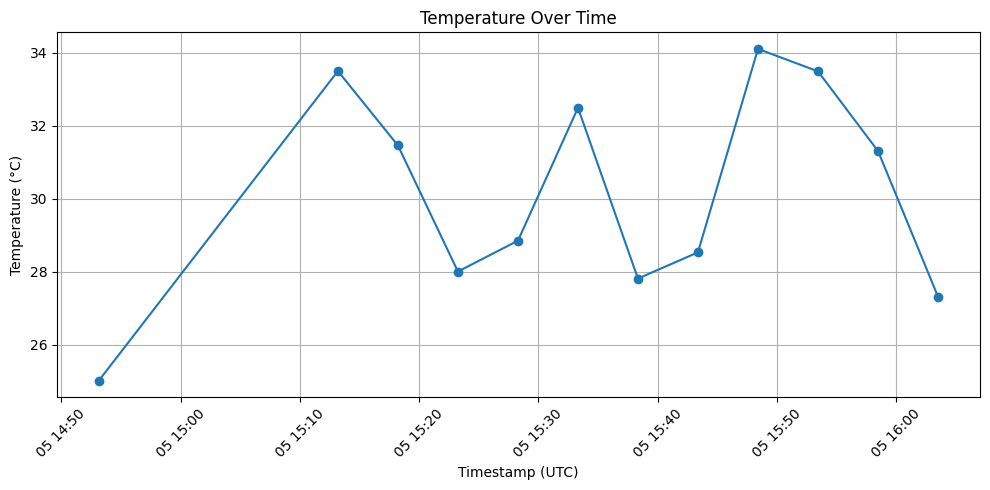

In [433]:
import pandas as pd
import os
from datetime import datetime, timezone
import matplotlib.pyplot as plt

os.environ['MPLCONFIGDIR'] = '/Users/george/.config/matplotlib'

# Only process 'temp' data
data = []
for entry in telemetry_data.get('temp', []):
    data.append({
        'timestamp': datetime.fromtimestamp(entry['ts'] / 1000, tz=timezone.utc),
        'temperature': float(entry['value'])
    })

df = pd.DataFrame(data)

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(df['timestamp'], df['temperature'], marker='o')
plt.xlabel('Timestamp (UTC)')
plt.ylabel('Temperature (°C)')
plt.title('Temperature Over Time')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


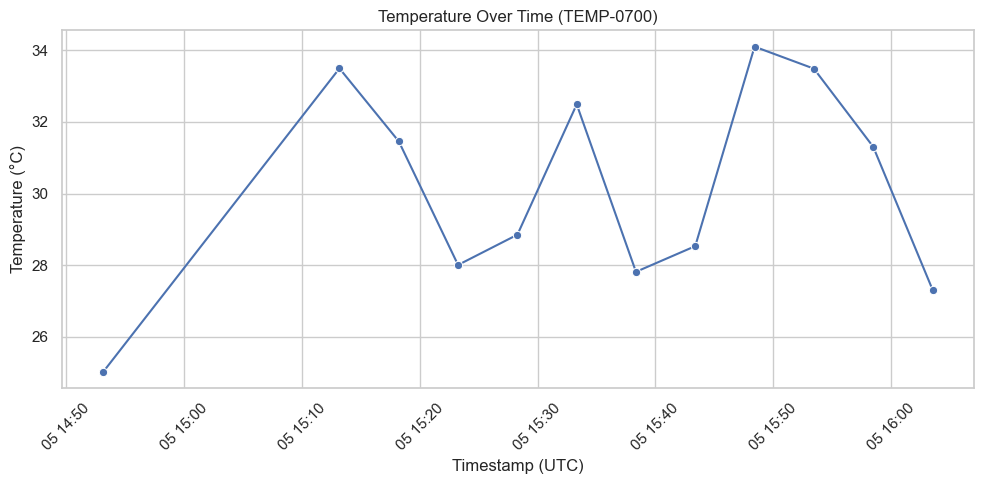

In [441]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime, timezone
import os

os.environ['MPLCONFIGDIR'] = '/Users/george/.config/matplotlib'

# Assuming telemetry_data is defined as the dictionary you posted
# telemetry_data = {
#     'deviceId': [{'ts': 1743869018853, 'value': 'TEMP-0700'}, ...],  # insert full dict
#     'unit': [{'ts': 1743869018853, 'value': 'degC'}, ...],
#     'temp': [{'ts': 1743869018853, 'value': '34.758302935443'}, ...]
# }

# Extract 'temp' data only
data = []
for entry in telemetry_data.get('temp', []):
    data.append({
        'timestamp': datetime.fromtimestamp(entry['ts'] / 1000, tz=timezone.utc),
        'temperature': float(entry['value'])
    })

df = pd.DataFrame(data)

# Plotting with seaborn
sns.set(style="whitegrid")
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x='timestamp', y='temperature', marker='o')

plt.xlabel('Timestamp (UTC)')
plt.ylabel('Temperature (°C)')
plt.title('Temperature Over Time (TEMP-0700)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


/var/folders/bw/zwn916250j389j86x0z9f6tr0000gn/T/ipykernel_91544/3780151913.py:57: UserWarning: Glyph 127777 (\N{THERMOMETER}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/bw/zwn916250j389j86x0z9f6tr0000gn/T/ipykernel_91544/3780151913.py:57: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
/Users/george/Documents/final_push/function-calling-for-sensors-at-the-edge/llm/env3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127777 (\N{THERMOMETER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/george/Documents/final_push/function-calling-for-sensors-at-the-edge/llm/env3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


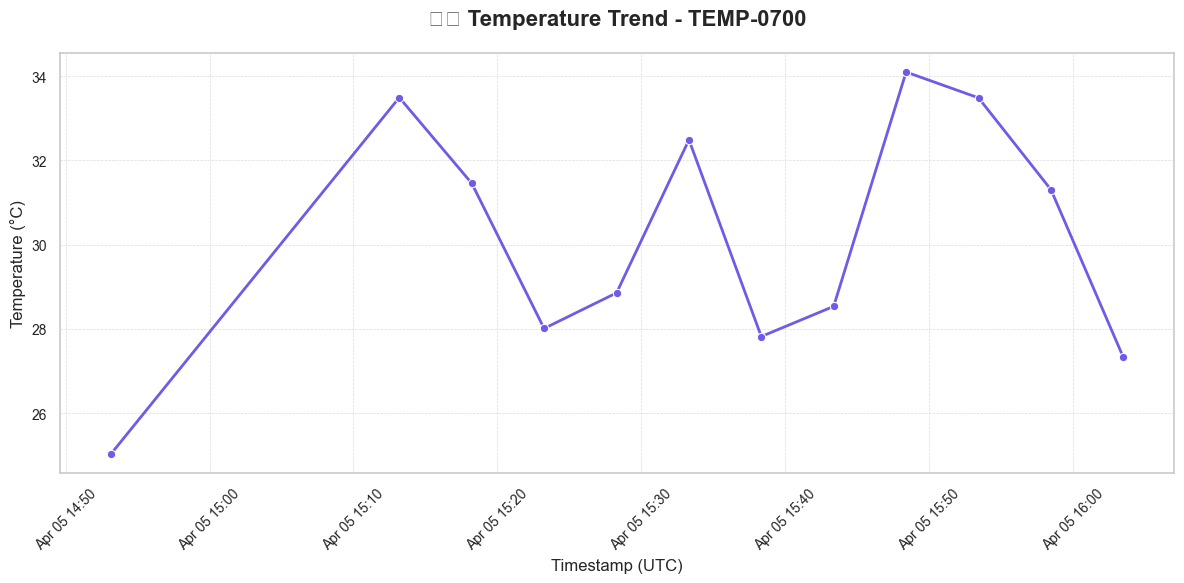

In [442]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timezone
import os

os.environ['MPLCONFIGDIR'] = '/Users/george/.config/matplotlib'

# Replace with your full telemetry data
# telemetry_data = {
#     'deviceId': [{'ts': 1743869018853, 'value': 'TEMP-0700'}, ...],  # insert full dict
#     'unit': [{'ts': 1743869018853, 'value': 'degC'}, ...],
#     'temp': [{'ts': 1743869018853, 'value': '34.758302935443'}, ...]
# }

# Extract 'temp' data
data = []
for entry in telemetry_data.get('temp', []):
    data.append({
        'timestamp': datetime.fromtimestamp(entry['ts'] / 1000, tz=timezone.utc),
        'temperature': float(entry['value'])
    })

df = pd.DataFrame(data)

# Apply a nice seaborn theme
sns.set_theme(style="whitegrid")

# Create the plot
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df,
    x='timestamp',
    y='temperature',
    marker='o',
    linewidth=2,
    markersize=6,
    color="#6C5CE7"  # a clean purple tone
)

# Format the x-axis timestamps
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d %H:%M', tz=timezone.utc))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())

# Labels and title with nice spacing
plt.title('🌡️ Temperature Trend - TEMP-0700', fontsize=16, weight='bold', pad=20)
plt.xlabel('Timestamp (UTC)', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)

# Rotate x-ticks and style them
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)

# Tight layout and subtle grid
plt.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()

plt.show()


In [1]:
print("Hello world")

Hello world


In [5]:
from typing import TypedDict
from typing import Literal 

In [48]:
class TypedDictState(TypedDict): 
    foo: str 
    bar: str 

In [59]:
class TypedDictState(TypedDict): 
    name: str 
    mood: Literal["happy", "sad"]

In [66]:
import random
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END

# # Define the expected state shape
# class TypedDictState(TypedDict):
#     name: str
#     mood: str

# Nodes
def node_1(state: TypedDictState) -> dict:
    print("---Node 1---")
    return {"name": state["name"] + " is ..."}

def node_2(state: TypedDictState) -> dict:
    print("---Node 2---")
    return {"mood": "happy"}

def node_3(state: TypedDictState) -> dict:
    print("---Node 3---")
    return {"mood": "sad"}

def decide_mood(state: TypedDictState) -> Literal["node_2", "node_3"]:
    return "node_2" if random.random() < 0.5 else "node_3"

# Build the graph
builder = StateGraph(TypedDictState)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

builder.add_edge(START, "node_1")
builder.add_conditional_edges("node_1", decide_mood)
builder.add_edge("node_2", END)
builder.add_edge("node_3", END)

# Compile
graph = builder.compile()

# Run
input_state = {"name": "Alice", "mood": ""}
final_state = graph.invoke(input_state)
print("Final State:", final_state)


---Node 1---
---Node 2---
Final State: {'name': 'Alice is ...', 'mood': 'happy'}


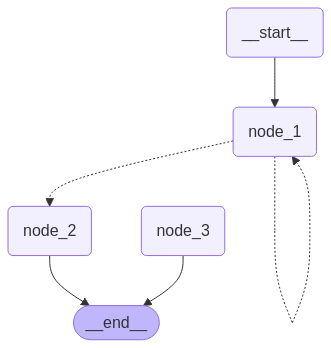

In [151]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))


In [152]:
from typing import Literal, TypedDict

class TypedDictState(TypedDict): 
    name: str 
    mood: Literal["sad", "happy"]

In [153]:
input_state = {"name": "Lance", "mood": ""}

In [156]:
def node_1(state: TypedDictState) -> dict: 
    return {"name": state["name"] +" is ...."}

def node_2(state: TypedDictState) -> dict: 
    return {"mood":"sad"}

def node_3(state: TypedDictState) -> dict: 
    return {"mood": "happy"}

def decide_mood(state: TypedDictState) -> Literal["node_2", "node_3"]: 
    return "node_2" if random.random() < 0.5 else "node_3"


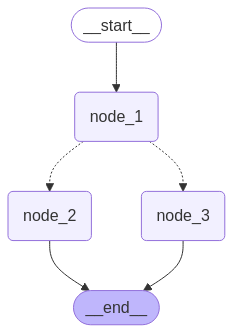

In [157]:
builder = StateGraph(TypedDictState)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

# Logic 
builder.add_edge(START, "node_1")
builder.add_conditional_edges("node_1", decide_mood)
builder.add_edge("node_2", END)
builder.add_edge("node_3", END)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [150]:
# Langchain combines {'name': 'Lance is ....'} + {'mood': 'sad'} ===> {'name': 'Lance is ... ', 'mood': 'happy'}

In [ ]:
return "node_2" if random.random() < 0.5 else "node_3"

In [158]:
from typing import TypedDict, Literal 

class TypedDictState(TypedDict): 
    name: str 
    mood: Literal["sad","happy"]

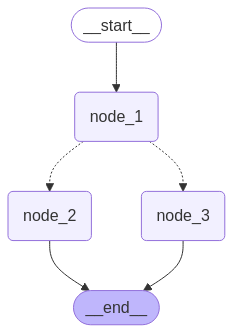

In [165]:
def node_1(state: TypedDictState) -> dict: 
    return {"name": state["name"] + " is ...."}

def node_2(state: TypedDictState) -> dict:
    return {"mood": "sad"}

def node_3(state: TypedDictState) -> dict:
    return {"mood": "happy"}

def decide_moode(state: TypedDictState) -> Literal["node_2", "node_3"]: 
    return "node_2" if random.random() < 0.5 else "node_3"

builder = StateGraph(TypedDictState)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

# Add logic 
builder.add_edge(START, "node_1")
builder.add_conditional_edges("node_1", decide_mood)
builder.add_edge("node_2", END)
builder.add_edge("node_3", END)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [182]:
from typing import TypedDict, Literal 

class TypedDictState(TypedDict): 
    name: str 
    mood: Literal["happy", "sad"]

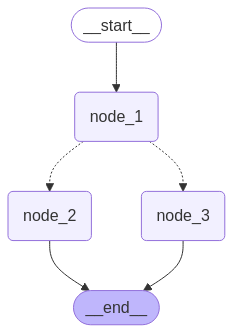

In [183]:
def node_1(state: TypedDictState) -> dict: 
    return {"name":state["name"] + " is...."}

def node_2(state: TypedDictState) -> dict: 
    return {"mood": "happy"}

def node_3(state: TypedDictState) -> dict: 
    return {"mood": "sad"}

def decide_mood(state: TypedDictState) -> Literal["node_2","node_3"]:
    return "node_2" if random.random() < 0.5 else "node_3"

builder = StateGraph(TypedDictState)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

# Logic 
builder.add_edge(START, "node_1")
builder.add_conditional_edges("node_1", decide_mood)
builder.add_edge("node_2", END)
builder.add_edge("node_3", END)
graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [185]:
graph.invoke({"name":"George"})

{'name': 'George is....', 'mood': 'happy'}

In [188]:
from pydantic import BaseModel, field_validator, ValidationError

class PydanticState(BaseModel): 
    name: str 
    mood: str 

    @field_validator('mood')
    @classmethod
    def validate_mood(cls, value): 
        if value not in ["happy", "sad"]: 
            raise ValueError("Error mood must be either 'happy" or 'sad')
        return value 
    

try:
    state = PydanticState(name="John Doe", mood="sad")
except ValidationError as e:
    print("Validation Error:", e)

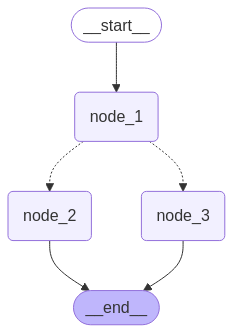

In [189]:
builder = StateGraph(PydanticState)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

# Logic 
builder.add_edge(START, "node_1")
builder.add_conditional_edges("node_1", decide_mood)
builder.add_edge("node_2", END)
builder.add_edge("node_3", END)
graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

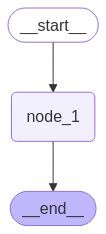

In [204]:
class TypedDictState(TypedDict): 
    foo: int 

def node_1(state: TypedDictState) -> dict: 
    print("---Node 1-----")
    return {"foo":state['foo'] + 1}

builder = StateGraph(TypedDictState)
builder.add_node("node_1",  node_1)

# Logic 
builder.add_edge(START, "node_1")
builder.add_edge("node_1", END)
graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [205]:
graph.invoke({"foo": 1})

---Node 1-----


{'foo': 2}

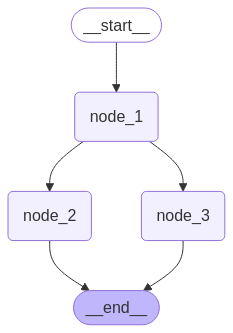

In [217]:
class TypedDictState(TypedDict): 
    foo: int 

def node_1(state: TypedDictState) -> dict: 
    print("---Node 1-----")
    return {"foo":state['foo'] + 1}

def node_2(state: TypedDictState) -> dict: 
    print("---Node 1-----")
    return {"foo":state['foo'] + 1}

def node_3(state: TypedDictState) -> dict: 
    print("---Node 1-----")
    return {"foo":state['foo'] + 1}


builder = StateGraph(TypedDictState)
builder.add_node("node_1",  node_1)
builder.add_node("node_2",  node_2)
builder.add_node("node_3",  node_3)

# Logic 
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_1", "node_3")
builder.add_edge("node_2",  END)
builder.add_edge("node_3",  END)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [215]:
from langgraph.errors import InvalidUpdateError
try:
    graph.invoke({"foo" : 1})
except InvalidUpdateError as e:
    print(f"InvalidUpdateError occurred: {e}")

---Node 1-----
---Node 1-----
---Node 1-----
InvalidUpdateError occurred: At key 'foo': Can receive only one value per step. Use an Annotated key to handle multiple values.
For troubleshooting, visit: https://python.langchain.com/docs/troubleshooting/errors/INVALID_CONCURRENT_GRAPH_UPDATE


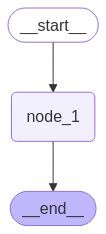

In [227]:
from operator import add
from typing import Annotated, List 

class TypedDictState(TypedDict): 
    foo: Annotated[List[int], add]

def node_1(state: TypedDictState) -> dict: 
    print("---Node 1-----")
    return {"foo":[state['foo'][0] + 1]}

builder = StateGraph(TypedDictState)
builder.add_node("node_1",  node_1)

# Logic 
builder.add_edge(START, "node_1")
builder.add_edge("node_1", END)
graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [228]:
graph.invoke({"foo" : [1]})

---Node 1-----


{'foo': [1, 2]}

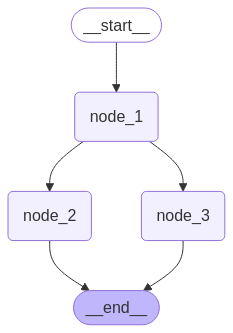

In [229]:
class TypedDictState(TypedDict): 
    foo: Annotated[List[int], add] 

def node_1(state: TypedDictState) -> dict: 
    print("---Node 1-----")
    return {"foo":[state['foo'][-1] + 1]}

def node_2(state: TypedDictState) -> dict: 
    print("---Node 1-----")
    return {"foo":[state['foo'][-1] + 1]}

def node_3(state: TypedDictState) -> dict: 
    print("---Node 1-----")
    return {"foo":[state['foo'][-1] + 1]}


builder = StateGraph(TypedDictState)
builder.add_node("node_1",  node_1)
builder.add_node("node_2",  node_2)
builder.add_node("node_3",  node_3)

# Logic 
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_1", "node_3")
builder.add_edge("node_2",  END)
builder.add_edge("node_3",  END)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [230]:
graph.invoke({"foo" : [1]})

---Node 1-----
---Node 1-----
---Node 1-----


{'foo': [1, 2, 3, 3]}

In [231]:
try:
    graph.invoke({"foo" : None})
except TypeError as e:
    print(f"TypeError occurred: {e}")

TypeError occurred: can only concatenate list (not "NoneType") to list


In [232]:
def reduce_list(left: list | None, right: list | None) -> list:
    """Safely combine two lists, handling cases where either or both inputs might be None.

    Args:
        left (list | None): The first list to combine, or None.
        right (list | None): The second list to combine, or None.

    Returns:
        list: A new list containing all elements from both input lists.
               If an input is None, it's treated as an empty list.
    """
    if not left:
        left = []
    if not right:
        right = []
    return left + right

class DefaultState(TypedDict):
    foo: Annotated[list[int], add]

class CustomReducerState(TypedDict):
    foo: Annotated[list[int], reduce_list]

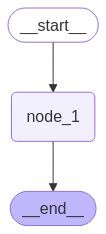

TypeError occurred: can only concatenate list (not "NoneType") to list


In [233]:
def node_1(state):
    print("---Node 1---")
    return {"foo": [2]}

# Build graph
builder = StateGraph(DefaultState)
builder.add_node("node_1", node_1)

# Logic
builder.add_edge(START, "node_1")
builder.add_edge("node_1", END)

# Add
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

try:
    print(graph.invoke({"foo" : None}))
except TypeError as e:
    print(f"TypeError occurred: {e}")

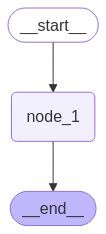

---Node 1---
{'foo': [2]}


In [234]:
# Build graph
builder = StateGraph(CustomReducerState)
builder.add_node("node_1", node_1)

# Logic
builder.add_edge(START, "node_1")
builder.add_edge("node_1", END)

# Add
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

try:
    print(graph.invoke({"foo" : None}))
except TypeError as e:
    print(f"TypeError occurred: {e}")

In [235]:
from typing import Annotated
from langgraph.graph import MessagesState
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages

# Define a custom TypedDict that includes a list of messages with add_messages reducer
class CustomMessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    added_key_1: str
    added_key_2: str
    # etc

# Use MessagesState, which includes the messages key with add_messages reducer
class ExtendedMessagesState(MessagesState):
    # Add any keys needed beyond messages, which is pre-built 
    added_key_1: str
    added_key_2: str
    # etc

In [236]:
from langgraph.graph.message import add_messages
from langchain_core.messages import AIMessage, HumanMessage

# Initial state
initial_messages = [AIMessage(content="Hello! How can I assist you?", name="Model"),
                    HumanMessage(content="I'm looking for information on marine biology.", name="Lance")
                   ]

# New message to add
new_message = AIMessage(content="Sure, I can help with that. What specifically are you interested in?", name="Model")

# Test
add_messages(initial_messages , new_message)

[AIMessage(content='Hello! How can I assist you?', additional_kwargs={}, response_metadata={}, name='Model', id='913dff96-733b-47f7-b628-ea16c3549553'),
 HumanMessage(content="I'm looking for information on marine biology.", additional_kwargs={}, response_metadata={}, name='Lance', id='4e7f14e2-abd4-4d77-b11d-5e467b566067'),
 AIMessage(content='Sure, I can help with that. What specifically are you interested in?', additional_kwargs={}, response_metadata={}, name='Model', id='d5fd68ce-1453-4b43-9a0e-b0bfd3366622')]

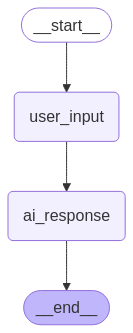

In [241]:
import random
from typing import Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, AIMessage, AnyMessage
from typing_extensions import TypedDict

# Extend the built-in MessagesState
class ExtendedMessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    chat_mode: str  # Extra info you can use in logic

# Define node 1 — simulates user input
def user_input_node(state: ExtendedMessagesState) -> dict:
    print(">>> Node: User Input")
    return {
        "messages": [HumanMessage(content="Hello, what’s the weather like?")]
    }

# Define node 2 — simulates AI response
def ai_response_node(state: ExtendedMessagesState) -> dict:
    print(">>> Node: AI Response")
    return {
        "messages": [AIMessage(content="It’s sunny and 24°C.")]
    }

# Build the graph
builder = StateGraph(ExtendedMessagesState)
builder.add_node("user_input", user_input_node)
builder.add_node("ai_response", ai_response_node)

builder.add_edge(START, "user_input")
builder.add_edge("user_input", "ai_response")
builder.add_edge("ai_response", END)

# Compile the graph
graph = builder.compile()
# View
display(Image(graph.get_graph().draw_mermaid_png()))


In [242]:
# Run the graph
initial_state = {
    "messages": [],  # Important: Start with empty message history
    "chat_mode": "weather_query"
}

final_state = graph.invoke(initial_state)

# Output the full conversation
print("\n=== Final Conversation ===")
for msg in final_state["messages"]:
    print(f"{msg.type.capitalize()}: {msg.content}")

>>> Node: User Input
>>> Node: AI Response

=== Final Conversation ===
Human: Hello, what’s the weather like?
Ai: It’s sunny and 24°C.


In [248]:
from typing import Annotated, Literal
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, AIMessage, AnyMessage
from typing_extensions import TypedDict
import random

# State with conditional routing key
class ExtendedMessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    chat_mode: Literal["weather_query", "math_query"]

# Node simulating user input
def user_input_node(state: ExtendedMessagesState) -> dict:
    print(">>> Node: User Input")
    if state["chat_mode"] == "weather_query":
        return {
            "messages": [HumanMessage(content="What’s the weather today?")]
        }
    else:
        return {
            "messages": [HumanMessage(content="What’s 5 + 7?")]
        }

# Node for weather response
def weather_response_node(state: ExtendedMessagesState) -> dict:
    print(">>> Node: Weather Response")
    return {
        "messages": [AIMessage(content="It’s cloudy and 19°C.")]
    }

# Node for math response
def math_response_node(state: ExtendedMessagesState) -> dict:
    print(">>> Node: Math Response")
    return {
        "messages": [AIMessage(content="5 + 7 = 12")]
    }

# Router function to decide next node
def decide_next_node(state: ExtendedMessagesState) -> Literal["weather_response", "math_response"]:
    if state["chat_mode"] == "weather_query":
        return "weather_response"
    else:
        return "math_response"

# Build graph
builder = StateGraph(ExtendedMessagesState)
builder.add_node("user_input", user_input_node)
builder.add_node("weather_response", weather_response_node)
builder.add_node("math_response", math_response_node)

builder.add_edge(START, "user_input")
builder.add_conditional_edges("user_input", decide_next_node)
builder.add_edge("weather_response", END)
builder.add_edge("math_response", END)

graph = builder.compile()


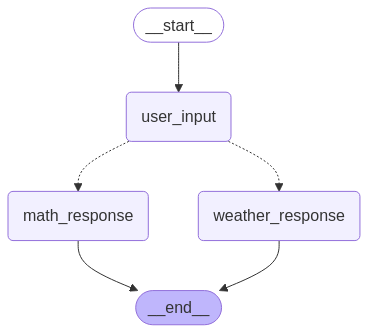

In [250]:
# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [249]:
# Test weather path
print("=== WEATHER QUERY ===")
graph.invoke({"messages": [], "chat_mode": "weather_query"})

# Test math path
print("\n=== MATH QUERY ===")
graph.invoke({"messages": [], "chat_mode": "math_query"})


=== WEATHER QUERY ===
>>> Node: User Input
>>> Node: Weather Response

=== MATH QUERY ===
>>> Node: User Input
>>> Node: Math Response


{'messages': [HumanMessage(content='What’s 5 + 7?', additional_kwargs={}, response_metadata={}, id='1f24bd2a-650f-487d-905f-d95fffedcbeb'),
  AIMessage(content='5 + 7 = 12', additional_kwargs={}, response_metadata={}, id='77c55f8e-9336-491d-bab8-5cfd01a459ff')],
 'chat_mode': 'math_query'}

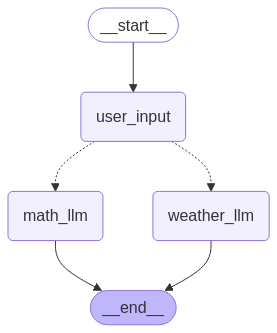

In [263]:
from typing import Annotated, Literal
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, AIMessage, AnyMessage
from typing_extensions import TypedDict
from langchain_openai import ChatOpenAI

# Define the state
class ExtendedMessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    chat_mode: Literal["weather_query", "math_query"]

# LLM setup
llm = ChatOpenAI(api_key=openai_api_key, model="gpt-3.5-turbo", temperature=0)

# User input node
def user_input_node(state: ExtendedMessagesState) -> dict:
    print(">>> Node: User Input")
    msg = (
        "What’s the weather like in Paris today?"
        if state["chat_mode"] == "weather_query"
        else "What is 17 * 23?"
    )
    return {
        "messages": [HumanMessage(content=msg)]
    }

# LLM node — same logic for both paths
def llm_response_node(state: ExtendedMessagesState) -> dict:
    print(f">>> Node: LLM Response ({state['chat_mode']})")
    response = llm.invoke(state["messages"])
    return {"messages": [response]}

# Router logic
def decide_next_node(state: ExtendedMessagesState) -> Literal["weather_llm", "math_llm"]:
    return "weather_llm" if state["chat_mode"] == "weather_query" else "math_llm"

# Build the graph
builder = StateGraph(ExtendedMessagesState)
builder.add_node("user_input", user_input_node)
builder.add_node("weather_llm", llm_response_node)
builder.add_node("math_llm", llm_response_node)

builder.add_edge(START, "user_input")
builder.add_conditional_edges("user_input", decide_next_node)
builder.add_edge("weather_llm", END)
builder.add_edge("math_llm", END)

graph = builder.compile()
# View
display(Image(graph.get_graph().draw_mermaid_png()))


In [260]:
# openai_api_key

In [262]:
# Weather example
weather_result = graph.invoke({"messages": [], "chat_mode": "weather_query"})
print("\n🌤️ Weather Answer:")
for m in weather_result["messages"]:
    print(f"{m.type}: {m.content}")

# Math example
math_result = graph.invoke({"messages": [], "chat_mode": "math_query"})
print("\n🧮 Math Answer:")
for m in math_result["messages"]:
    print(f"{m.type}: {m.content}")


>>> Node: User Input
>>> Node: LLM Response (weather_query)

🌤️ Weather Answer:
human: What’s the weather like in Paris today?
ai: I'm sorry, I am an AI assistant and I do not have real-time information. I recommend checking a reliable weather website or app for the most up-to-date weather information in Paris.
>>> Node: User Input
>>> Node: LLM Response (math_query)

🧮 Math Answer:
human: What is 17 * 23?
ai: 391


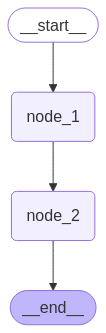

In [273]:
# Private State 
from typing_extensions import TypedDict
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

class OverallState(TypedDict):
    foo: int 

class PrivateState(TypedDict): 
    baz: int 

def node_1(state: OverallState) -> PrivateState: 
    print("---node 1----")
    return {"baz":state["foo"] + 1}

def node_2(state: PrivateState) -> OverallState: 
    print("---node 2---")
    return {"foo":state["baz"] + 1}

builder = StateGraph(OverallState)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)

# Logic 
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_2", END)


graph = builder.compile()
# View
display(Image(graph.get_graph().draw_mermaid_png()))

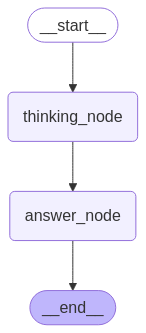

In [276]:
class OverallState(TypedDict): 
    question: str
    answer: str 
    notes: str 

def thinking_node(state: OverallState) -> dict:
    return {"answer":"bye", "note":" ...his name is Lance"}

def answer_node(state: OverallState) -> dict: 
    return {"answer":"bye Lance"}


builder = StateGraph(OverallState)
builder.add_node("thinking_node", thinking_node)
builder.add_node("answer_node", answer_node)

# Logic 
builder.add_edge(START,"thinking_node")
builder.add_edge("thinking_node","answer_node")
builder.add_edge("answer_node", END)

graph = builder.compile()
# View
display(Image(graph.get_graph().draw_mermaid_png()))


In [277]:
graph.invoke({"question":"Hi"})

{'question': 'Hi', 'answer': 'bye Lance'}

/var/folders/bw/zwn916250j389j86x0z9f6tr0000gn/T/ipykernel_66464/3950774097.py:19: LangGraphDeprecationWarning: Initializing StateGraph without state_schema is deprecated. Please pass in an explicit state_schema instead of just an input and output schema.
  builder = StateGraph(input=InputState, output=OutputState)


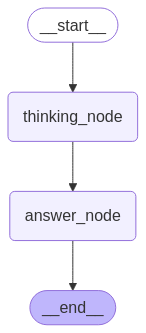

In [278]:
class InputState(TypedDict):
    question: str 

class OutputState(TypedDict):
    answer: str 

class OverallState(TypedDict): 
    question: str
    answer: str 
    notes: str 

def thinking_node(state: OverallState) -> dict:
    return {"answer":"bye", "note":" ...his name is Lance"}

def answer_node(state: OverallState) -> dict: 
    return {"answer":"bye Lance"}


builder = StateGraph(input=InputState, output=OutputState)
builder.add_node("thinking_node", thinking_node)
builder.add_node("answer_node", answer_node)

# Logic 
builder.add_edge(START,"thinking_node")
builder.add_edge("thinking_node","answer_node")
builder.add_edge("answer_node", END)

graph = builder.compile()
# View
display(Image(graph.get_graph().draw_mermaid_png()))


In [279]:
graph.invoke({"question":"Hi"})

{'answer': 'bye Lance'}

In [290]:
a = {"sensors": ["MOIST-0500"]}
a

{'sensors': ['MOIST-0500']}

In [297]:
a['sensors']

['MOIST-0500']

In [296]:
a.values()

dict_values([['MOIST-0500']])